# Types Of Events & Probability Rules

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:

# Reproducibility
np.random.seed(100)

# Airline Booking Dataset
Airline = pd.DataFrame({

    "Booking_ID": range(5001, 5301),

    "Customer_Age": np.random.randint(18, 70, 300),

    "Ticket_Class": np.random.choice(
        ["Economy", "Premium Economy", "Business"],
        300,
        p=[0.65, 0.20, 0.15]
    ),

    "Booking_Status": np.random.choice(
        ["Confirmed", "Cancelled", "Pending"],
        300,
        p=[0.75, 0.10, 0.15]
    ),

    "Payment_Method": np.random.choice(
        ["Credit Card", "Debit Card", "UPI", "Net Banking"],
        300,
        p=[0.35, 0.20, 0.30, 0.15]
    ),

    "Travel_Insurance": np.random.choice(
        ["Yes", "No"],
        300,
        p=[0.40, 0.60]
    ),

    "Flight_Type": np.random.choice(
        ["Domestic", "International"],
        300,
        p=[0.70, 0.30]
    ),

    "Seat_Type": np.random.choice(
        ["Window", "Aisle", "Middle"],
        300,
        p=[0.40, 0.35, 0.25]
    )
})

Airline.head()

,Booking_ID,Customer_Age,Ticket_Class,Booking_Status,Payment_Method,Travel_Insurance,Flight_Type,Seat_Type
0,5001,26,Economy,Confirmed,Debit Card,Yes,Domestic,Middle
1,5002,42,Economy,Confirmed,UPI,No,Domestic,Window
2,5003,21,Economy,Confirmed,Credit Card,No,International,Aisle
3,5004,57,Economy,Confirmed,Credit Card,Yes,International,Aisle
4,5005,41,Economy,Confirmed,Net Banking,No,Domestic,Aisle


In [4]:
Airline.shape

(300, 8)

In [5]:
Airline.columns

Index(['Booking_ID', 'Customer_Age', 'Ticket_Class', 'Booking_Status',
       'Payment_Method', 'Travel_Insurance', 'Flight_Type', 'Seat_Type'],
      dtype='object')

In [10]:
Airline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Booking_ID        300 non-null    int64 
 1   Customer_Age      300 non-null    int32 
 2   Ticket_Class      300 non-null    object
 3   Booking_Status    300 non-null    object
 4   Payment_Method    300 non-null    object
 5   Travel_Insurance  300 non-null    object
 6   Flight_Type       300 non-null    object
 7   Seat_Type         300 non-null    object
dtypes: int32(1), int64(1), object(6)
memory usage: 17.7+ KB


In [11]:
Airline.describe(include='all')

,Booking_ID,Customer_Age,Ticket_Class,Booking_Status,Payment_Method,Travel_Insurance,Flight_Type,Seat_Type
count,300.000000,300.000000,300,300,300,300,300,300
unique,NaN,NaN,3,3,4,2,2,3
top,NaN,NaN,Economy,Confirmed,Credit Card,No,Domestic,Window
freq,NaN,NaN,200,218,107,174,221,114
mean,5150.500000,43.776667,NaN,NaN,NaN,NaN,NaN,NaN
std,86.746758,15.349010,NaN,NaN,NaN,NaN,NaN,NaN
min,5001.000000,18.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,5075.750000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,5150.500000,45.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,5225.250000,56.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
Airline.isnull().sum()

Booking_ID          0
Customer_Age        0
Ticket_Class        0
Booking_Status      0
Payment_Method      0
Travel_Insurance    0
Flight_Type         0
Seat_Type           0
dtype: int64

###  Event

    An event is one or more outcomes of interest from the sample space.

    It represents the occurrence of a specific condition or result in a random experiment.

### Example
    Experiment:
        Randomly select one airline booking.
    Event:
        The selected booking is Confirmed.

## Types Of Event

### 1.Simple Event 
    A Simple Event Contains Only One Outcome.

    Example
        A randomly selected booking is confirmed

In [15]:
total=len(Airline)

confirmed=len(
Airline[
Airline["Booking_Status"]=="Confirmed"
])

P=confirmed/total

print(P)

0.7266666666666667


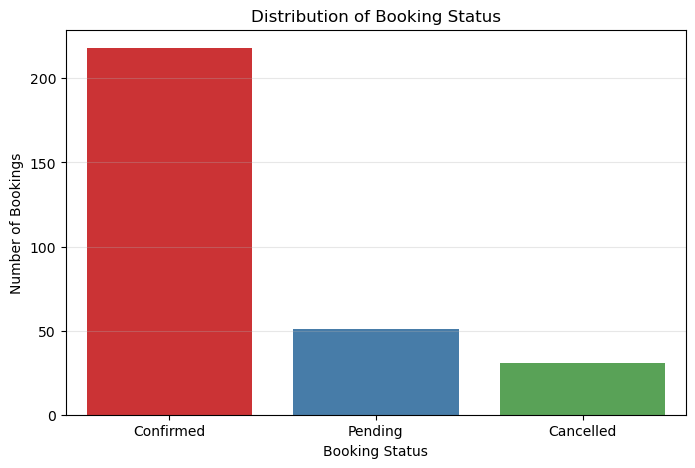

In [45]:

plt.figure(figsize=(8,5))

sns.countplot(
    data=Airline,
    x="Booking_Status",
    hue="Booking_Status",
    palette="Set1",
    legend=False
)

plt.title("Distribution of Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")

plt.grid(axis="y", alpha=0.3)

plt.show()

### 2.Compound Event
    A Compound Event consists of two or more events occurring together.
    Example:
        Booking is Confirmed And Travel Insurance is Purchased.

In [16]:
compound=len(

Airline[
(Airline["Booking_Status"]=="Confirmed") &
(Airline["Travel_Insurance"]=="Yes")
]

)/len(Airline)

print(compound)

0.31


### 3.Independent Event
    Two events are independent  if the occurrence of one event does not affect the probability of other. 
    Ex:
        Payment Methods
        Travel Insurance
        
    Event A: Customer chooses Window Seat
    Event B: Customer pays using UPI

In [20]:
# Total Bookings
total = len(Airline)

# Event A
A = len(Airline[Airline["Seat_Type"] == "Window"])

# Event B
B = len(Airline[Airline["Payment_Method"] == "UPI"])

# Probabilities
P_A = A / total
P_B = B / total

# Independent Probability
P_A_and_B = P_A * P_B

print(f"P(Window Seat) = {P_A:.3f}")
print(f"P(UPI Payment) = {P_B:.3f}")
print(f"P(Window AND UPI) = {P_A_and_B:.3f}")

P(Window Seat) = 0.380
P(UPI Payment) = 0.277
P(Window AND UPI) = 0.105


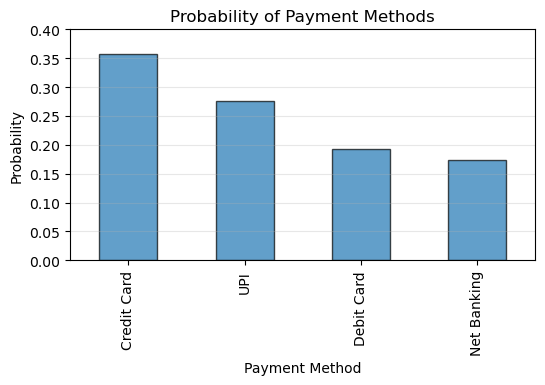

In [57]:
payment_prob = Airline["Payment_Method"].value_counts(normalize=True)

plt.figure(figsize=(6,3))

payment_prob.plot(
    kind="bar",
    edgecolor="black",
    alpha=0.7
)

plt.title("Probability of Payment Methods")

plt.xlabel("Payment Method")

plt.ylabel("Probability")

plt.ylim(0,0.40)

plt.grid(axis="y", alpha=0.3)

plt.show()

### 4.Dependent Event
    Two events are dependent if the occurence of one event changes the probability of another.
    Ex:
        Business Class passengers are more likely to purchase travel insurance.

    Event A: Customer books Business Class
    Event B: Customer purchases Travel Insurance

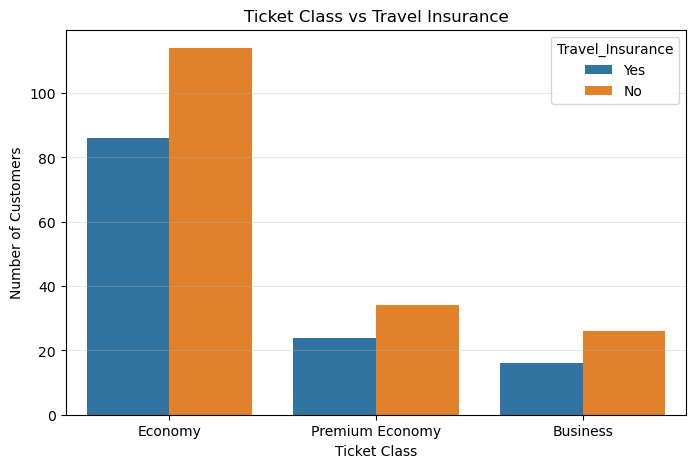

In [58]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=Airline,
    x="Ticket_Class",
    hue="Travel_Insurance"
)

plt.title("Ticket Class vs Travel Insurance")

plt.xlabel("Ticket Class")

plt.ylabel("Number of Customers")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [21]:
# Business Class Customers
business = Airline[Airline["Ticket_Class"] == "Business"]

# Conditional Probability
P_insurance_given_business = (
    len(business[business["Travel_Insurance"] == "Yes"])
    / len(business)
)

print("P(Travel Insurance | Business Class) =",
      round(P_insurance_given_business,3))

P(Travel Insurance | Business Class) = 0.381


In [42]:
print('Relationship:-\n',
pd.crosstab(
    Airline["Ticket_Class"],
    Airline["Travel_Insurance"],
    margins=True
) )

Relationship:-
 Travel_Insurance   No  Yes  All
Ticket_Class                   
Business           26   16   42
Economy           114   86  200
Premium Economy    34   24   58
All               174  126  300


### 5.Mutually Exclusive Events
    Two events cannot occur at the same time.

    Ex:
        A booking cannot be both Cancelled and Confirmed simultaneously.
    

In [43]:
confirmed = len(
    Airline[Airline["Booking_Status"] == "Confirmed"]
)

cancelled = len(
    Airline[Airline["Booking_Status"] == "Cancelled"]
)

both = len(
    Airline[
        (Airline["Booking_Status"] == "Confirmed") &
        (Airline["Booking_Status"] == "Cancelled")
    ]
)

print("Confirmed :", confirmed)
print("Cancelled :", cancelled)

if both == 0:
    print("\nEvents are Mutually Exclusive.")

else:
    print("\nEvents are not Mutually Exclusive.")




Confirmed : 218
Cancelled : 31

Events are Mutually Exclusive.


### 6.Exhaustive Event
    The complete set of all possible outcomes.

    Ex:
        Booking Status Confirmed,Cancelled,Pending

In [37]:
print('Total:-',Airline["Booking_Status"].value_counts().sum())
print('\n')
print(Airline["Booking_Status"].value_counts())
print('\n')
print("Possible Booking Statuses:")

print(Airline["Booking_Status"].unique())

Total:- 300


Booking_Status
Confirmed    218
Pending       51
Cancelled     31
Name: count, dtype: int64


Possible Booking Statuses:
['Confirmed' 'Pending' 'Cancelled']


### 7. Impossible Event
    An impossible event is an event that can never occur.

    Probability:
$$
P(E)=0
$$
  
    Example:
         Getting a 7 when rolling a standard six-sided dice.


### 8. Certain Event
    A certain event is an event that will always occur.
    
    Probability:
$$
P(E)=1
$$

    Example:
        Getting a number less than 7 when rolling a standard six-sided dice.

### 9. Equally Likely Event
    Two or more events are equally likely if each event has the same probability of occurring.

    Example:
        Tossing a fair coin.
        
        Probability of Head:
$$
P(\text{Head})=\frac{1}{2}
$$

        Probability of Tail:

$$
P(\text{Tail})=\frac{1}{2}
$$

        Both outcomes have an equal chance of occurring.


### 10. Possible Event

    A possible event is an event that has a chance of occurring.

    Probability:
$$
0 < P(E) < 1
$$

    Example:
        Getting an even number when rolling a dice.

    Probability:
$$
P(E)=\frac{3}{6}=0.5
$$

### Probability Rules
    Probability Rules are mathematical rules that help us calculate the probability of one or more events occurring.

    They are used when we want to find probabilities involving multiple events, such as:

    Event A or Event B
    Event A and Event B
    Event A does not occur

### Addition Rule
    Used to calculate the probability of either one event or another occuring.

    Formula:

$$
P(A \cup B)=P(A)+P(B)-P(A \cap B)
$$

    Where:
        - P(A) = Probability of Event A
        - P(B)= Probability of Event B
        - P(A ∩ B) = Probability of both A and B
        - P(A ∪ B) = Probability of A or B
### What is the probability that a booking is either Confirmed OR Pending?

In [66]:
# Total bookings
total = len(Airline)

# Event A: Confirmed
A = len(Airline[Airline["Booking_Status"] == "Confirmed"])

# Event B: Pending
B = len(Airline[Airline["Booking_Status"] == "Pending"])

# Intersection (should be 0 because mutually exclusive)
A_and_B = len(
    Airline[
        (Airline["Booking_Status"] == "Confirmed") &
        (Airline["Booking_Status"] == "Pending")
    ]
)

# Addition Rule
P = (A / total) + (B / total) - (A_and_B / total)

print(f"P(Confirmed OR Pending) = {P:.3f}")

P(Confirmed OR Pending) = 0.897


### Multiplecation Rule
    Used to calculate the probability of two events occurring together.

    Formula:

$$
P(A \cap B)=P(A)\times P(B)
$$

    Where:

    - P(A) = Probability of Event A
    - P(B) = Probability of Event B
    - P(A ∩ B) = Probability that both Event A and Event B occur together

     Note:- This formula is applicable when Event A and Event B are independent events.

### What is the probability that a customer booked Business Class AND purchased Travel Insurance?

In [67]:
# Total bookings
total = len(Airline)

# Customers who satisfy both conditions
both = Airline[
    (Airline["Ticket_Class"] == "Business") &
    (Airline["Travel_Insurance"] == "Yes")
]

P = len(both) / total

print(f"P(Business Class AND Insurance) = {P:.3f}")

P(Business Class AND Insurance) = 0.053


In [68]:
P_A = len(
    Airline[Airline["Seat_Type"] == "Window"]
) / len(Airline)

P_B = len(
    Airline[Airline["Payment_Method"] == "UPI"]
) / len(Airline)

P_A_and_B = P_A * P_B

print(f"P(Window AND UPI) = {P_A_and_B:.3f}")

P(Window AND UPI) = 0.105


### Complement Rule
    The probability that an event does not occur.
    
    Formula:
$$
P(A') = 1 - P(A)
$$

    Where:
        P(A)= Probability of Event A
        P(A') = Probability that Event A does not occur

    The complement of an event represents all outcomes that are not included in the event.

### What is the probability that a booking is Not Confirmed?

In [5]:
# Total bookings
total = len(Airline)

# Confirmed bookings
confirmed = len(
    Airline[Airline["Booking_Status"] == "Confirmed"]
)

P_confirmed = confirmed / total

P_not_confirmed = 1 - P_confirmed

print(f"P(Confirmed) = {P_confirmed:.3f}")
print(f"P(Not Confirmed) = {P_not_confirmed:.3f}")

P(Confirmed) = 0.727
P(Not Confirmed) = 0.273


### Joint Probability
    Joint Probability is the probability that two events occur simultaneously.

$$
P(A \cap B)=\frac{\text{Number of outcomes where both A and B occur}}{\text{Total Number of Outcomes}}
$$

    For independent events,

$$
P(A \cap B)=P(A)\times P(B)
$$

    Where:
        - P(A \cap B)= Probability that both Event A and Event B occur together.
        - P(A) = Probability of Event A.
        - P(B) = Probability of Event B.

In [6]:
df = pd.DataFrame({
    "Purchased": [30, 40],
    "Not Purchased": [20, 10]
}, index=["Male", "Female"])

print(df)

total = df.values.sum()

joint_probability = df.loc["Male", "Purchased"] / total

print(f"Joint Probability (Male & Purchased): {joint_probability:.2f}")

        Purchased  Not Purchased
Male           30             20
Female         40             10
Joint Probability (Male & Purchased): 0.30


### Using Normalize=True Gives Joint Probability

In [8]:
df = pd.DataFrame({
    "Gender": ["Male","Male","Male","Female","Female","Female","Male","Female","Male","Female"],
    "Purchased": ["Yes","No","Yes","Yes","No","Yes","No","Yes","Yes","No"]
})


joint_prob = pd.crosstab(
    df["Gender"],
    df["Purchased"],
    normalize=True
)

joint_prob

Purchased,No,Yes
Gender,,
Female,0.2,0.3
Male,0.2,0.3


### Marginal Probability 
    Marginal Probability is the probability of a single event occurring, irrespective of any other event.

$$
P(A)=\frac{\text{Total outcomes in Event A}}{\text{Total Number of Outcomes}}
$$

    Similarly,

$$
P(B)=\frac{\text{Total outcomes in Event B}}{\text{Total Number of Outcomes}}
$$

    Where:
        - P(A) = Probability of Event A.
        - P(B) = Probability of Event B.
        - Total outcomes in Event A/B= Row total or Column total in the contingency table.
        - Total Number of Outcomes= Grand Total.

In [7]:
df = pd.DataFrame({
    "Purchased": [30, 40],
    "Not Purchased": [20, 10]
}, index=["Male", "Female"])

print(df)

total = df.values.sum()

# Row marginal probability
male_probability = df.loc["Male"].sum() / total

# Column marginal probability
purchase_probability = df["Purchased"].sum() / total

print(f"Marginal Probability (Male): {male_probability:.2f}")
print(f"Marginal Probability (Purchased): {purchase_probability:.2f}")

        Purchased  Not Purchased
Male           30             20
Female         40             10
Marginal Probability (Male): 0.50
Marginal Probability (Purchased): 0.70


### Joints + Marginal Probability

In [9]:
# Joint + Marginal Probability
pd.crosstab(df["Gender"], df["Purchased"], normalize=True, margins=True)

Purchased,No,Yes,All
Gender,,,
Female,0.2,0.3,0.5
Male,0.2,0.3,0.5
All,0.4,0.6,1.0


### Conditional Probability
    Conditional Probability is the probability of an event occurring given that another event has already occurred.
$$
P(A|B)=\frac{P(A\cap B)}{P(B)}
$$

    Where:
        P(A | B) = Probability of Event A given Event B has occurred.
        P(A ∩ B) = Probability of both A and B occurring together.
        P(B) = Probability of Event B.

### Business Example
    Suppose an airline wants to know:
        - Event A: Customer purchased Travel Insurance.
        - Event B: Customer booked Business Class.

    Conditional Probability answers the question:
        What is the probability that a customer purchased travel insurance, given that they booked Business Class?

### What is the probability that a customer purchased Travel Insurance, given that they booked Business Class?

    Mathematically,
$$
        P(Insurance ∣ Business Class)
$$

In [38]:
# Customers who booked Business Class
business = Airline[Airline["Ticket_Class"] == "Business"]

# Customers who booked Business Class and purchased Insurance
business_insurance = business[
    business["Travel_Insurance"] == "Yes"
]

# Conditional Probability
P = len(business_insurance) / len(business)

print(f"P(Insurance | Business Class) = {P:.3f}")

P(Insurance | Business Class) = 0.381


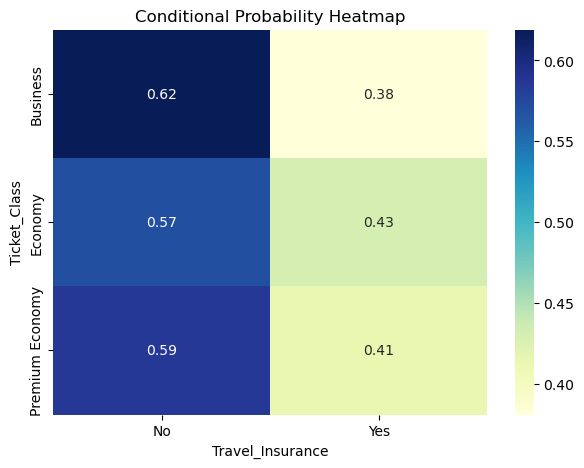

In [59]:
cross = pd.crosstab(
    Airline["Ticket_Class"],
    Airline["Travel_Insurance"],
    normalize="index"
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cross,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Conditional Probability Heatmap")

plt.show()

### Bayes' Theorem
    Bayes' Theorem is used to update the probability of an event based on new information or evidence.
$$
P(A|B)=\frac{P(B|A)\times P(A)}{P(B)}
$$

    Where:
        - P(A | B) = Posterior Probability
        - P(B | A) = Likelihood
        - P(A) = Prior Probability
        - P(B) = Total Probability of Event B

### Business Example
    Suppose:
        - Event A: Customer books Business Class.
        - Event B: Customer purchases Travel Insurance.

    Bayes' Theorem answers the question:
        What is the probability that a customer booked Business Class, given that they purchased Travel Insurance?

        Bayes' Theorem is widely used in fraud detection, spam email filtering, medical diagnosis, recommendation systems, and machine learning.

### What is the probability that a customer booked Business Class, given that they purchased Travel Insurance?

    Mathematically,
$$
P(Business Class∣Insurance)
$$

In [39]:
# Total bookings
total = len(Airline)

# P(Business Class)
P_A = len(
    Airline[Airline["Ticket_Class"] == "Business"]
) / total

# P(Insurance)
P_B = len(
    Airline[Airline["Travel_Insurance"] == "Yes"]
) / total

# P(Insurance | Business Class)
business = Airline[
    Airline["Ticket_Class"] == "Business"
]

P_B_given_A = len(
    business[business["Travel_Insurance"] == "Yes"]
) / len(business)

# Bayes' Theorem
P_A_given_B = (P_B_given_A * P_A) / P_B

print(f"P(Business Class | Insurance) = {P_A_given_B:.3f}")

P(Business Class | Insurance) = 0.127


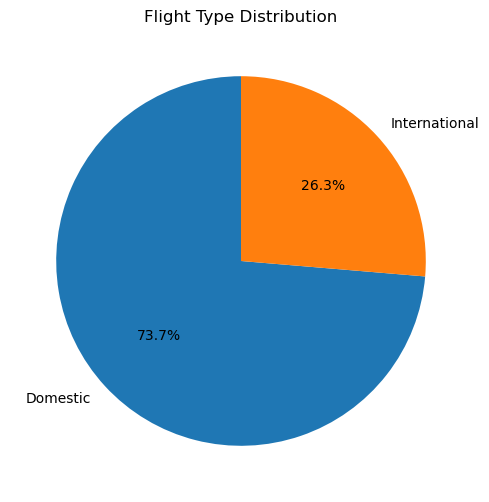

In [64]:
plt.figure(figsize=(6,6))

Airline["Flight_Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
    
)

plt.ylabel("")

plt.title("Flight Type Distribution")

plt.show()

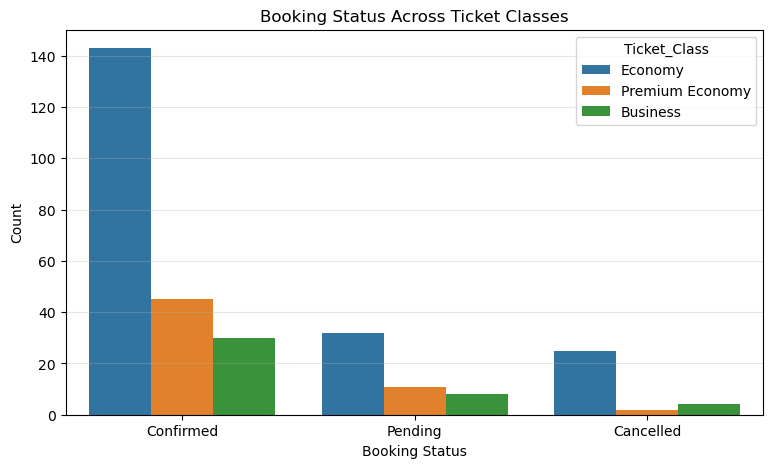

In [61]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=Airline,
    x="Booking_Status",
    hue="Ticket_Class"
)

plt.title("Booking Status Across Ticket Classes")

plt.xlabel("Booking Status")

plt.ylabel("Count")

plt.grid(axis="y", alpha=0.3)

plt.show()